# Radiation Damage Physics in 4H-SiC

This notebook presents the radiation damage physics model for 4H-SiC detectors under proton irradiation.
Three key effects are covered:

1. **Defect introduction** -- Z1/2, EH6/7, and EH4 centers created linearly with fluence
2. **Carrier lifetime degradation** -- Shockley-Read-Hall recombination via radiation-induced traps
3. **Carrier removal** -- Effective doping reduction leading to full compensation at critical fluence

All constants are calibrated to 1 MeV neutron equivalent and scaled to proton energies via NIEL hardness factors.

**Reference:** Burin et al., arXiv:2407.16710 (2024)

**Note:** NIEL hardness factors are placeholders pending SR-NIEL calculator lookup.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.radiation_damage import (
    RadiationDamageParams, defect_concentrations, degraded_lifetime,
    effective_doping, compute_K_tau, scale_to_proton_energy,
    apply_carrier_removal, NIEL_HARDNESS_PROTON_SIC,
)

params = RadiationDamageParams()
plt.rcParams.update({"font.family": "serif", "font.size": 12, "figure.dpi": 150})
print(f"Loaded RadiationDamageParams: source={params.source}")

Loaded RadiationDamageParams: source=Burin et al., arXiv:2407.16710 (2024)


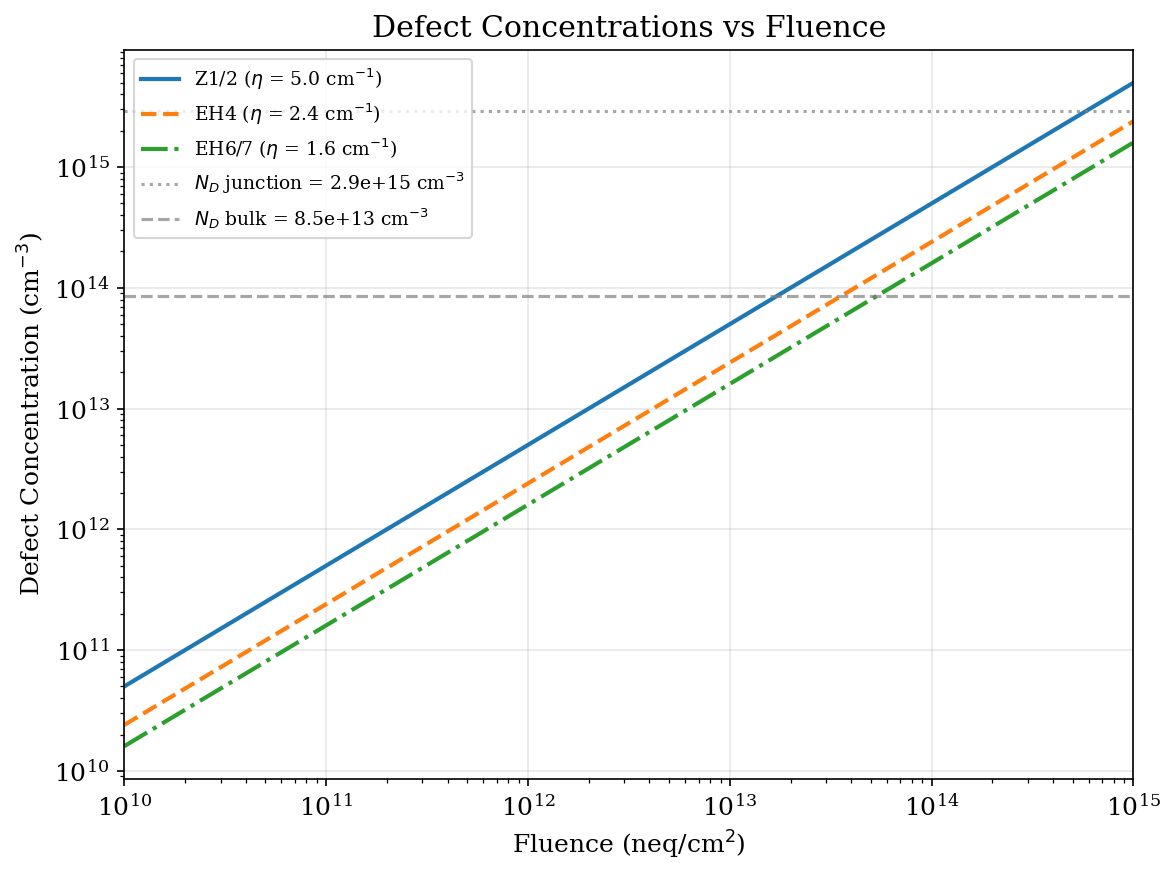

Saved: figures/09_defect_introduction.png


In [2]:
# Defect Introduction Rates vs Fluence
fluence = np.logspace(10, 15, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for label, eta, color, ls in [
    ("Z1/2 ($\\eta$ = 5.0 cm$^{-1}$)", params.eta_Z12, "#1f77b4", "-"),
    ("EH4 ($\\eta$ = 2.4 cm$^{-1}$)", params.eta_EH4, "#ff7f0e", "--"),
    ("EH6/7 ($\\eta$ = 1.6 cm$^{-1}$)", params.eta_EH67, "#2ca02c", "-."),
]:
    ax.loglog(fluence, eta * fluence, label=label, color=color, ls=ls, lw=2)

# Reference doping levels
N_D_junction = 2.9e15
N_D_bulk = 8.5e13
ax.axhline(N_D_junction, color="gray", ls=":", alpha=0.7, label=f"$N_D$ junction = {N_D_junction:.1e} cm$^{{-3}}$")
ax.axhline(N_D_bulk, color="gray", ls="--", alpha=0.7, label=f"$N_D$ bulk = {N_D_bulk:.1e} cm$^{{-3}}$")

ax.set_xlabel("Fluence (neq/cm$^2$)")
ax.set_ylabel("Defect Concentration (cm$^{-3}$)")
ax.set_title("Defect Concentrations vs Fluence")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(1e10, 1e15)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/09_defect_introduction.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/09_defect_introduction.png")

## Defect Parameters Summary

| Defect | Type | $\eta$ (cm$^{-1}$) | $E_T$ (eV below $E_c$) | $\sigma_n$ (cm$^2$) | $\sigma_p$ (cm$^2$) |
|--------|------|---------------------|------------------------|---------------------|---------------------|
| Z1/2   | Acceptor | 5.0 | 0.67 | 2.0e-14 | 3.5e-14 |
| EH6/7  | Donor    | 1.6 | 1.60 | 9.0e-12 | 3.8e-14 |
| EH4    | Acceptor | 2.4 | 1.03 | 5.0e-13 | 5.0e-14 |

Source: Burin et al., arXiv:2407.16710 (2024), Table I. Introduction rates are for 1 MeV neutron equivalent.

K_tau (electron) = 2.0897e-04 cm^2/s
K_tau (hole)     = 4.1555e-06 cm^2/s


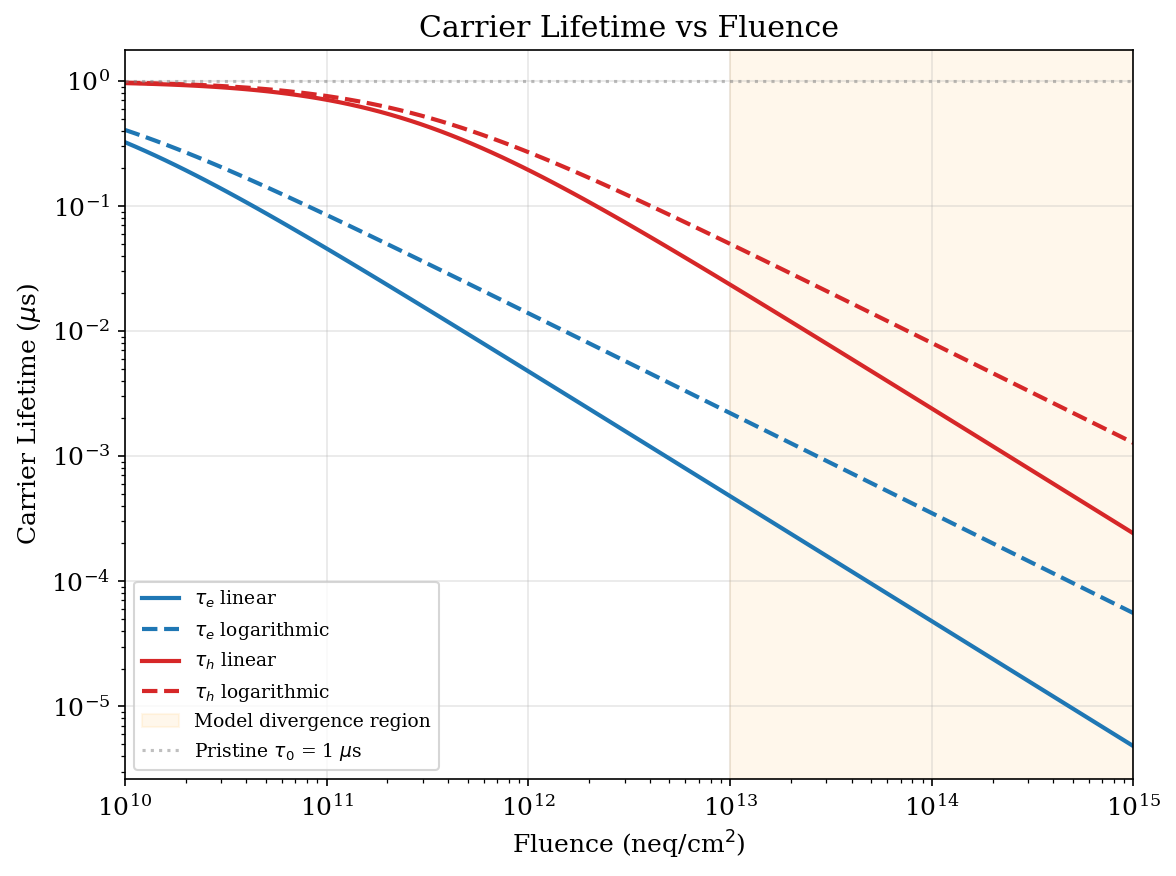

Saved: figures/09_lifetime_degradation.png


In [3]:
# Lifetime Degradation: Linear vs Logarithmic Models
tau_0 = 1e-6  # 1 us pristine lifetime
K_tau_n = compute_K_tau(params, carrier="electron", T=300.0)
K_tau_p = compute_K_tau(params, carrier="hole", T=300.0)
print(f"K_tau (electron) = {K_tau_n:.4e} cm^2/s")
print(f"K_tau (hole)     = {K_tau_p:.4e} cm^2/s")

fig, ax = plt.subplots(figsize=(8, 6))

for label, K, color in [
    ("electron", K_tau_n, "#1f77b4"),
    ("hole", K_tau_p, "#d62728"),
]:
    tau_lin = np.array([degraded_lifetime(tau_0, K, phi, model="linear") for phi in fluence])
    tau_log = np.array([degraded_lifetime(tau_0, K, phi, model="logarithmic") for phi in fluence])
    ax.loglog(fluence, tau_lin * 1e6, label=f"$\\tau_{{{label[0]}}}$ linear", color=color, ls="-", lw=2)
    ax.loglog(fluence, tau_log * 1e6, label=f"$\\tau_{{{label[0]}}}$ logarithmic", color=color, ls="--", lw=2)

# Annotate divergence region
ax.axvspan(1e13, 1e15, alpha=0.08, color="orange", label="Model divergence region")
ax.axhline(tau_0 * 1e6, color="gray", ls=":", alpha=0.5, label=f"Pristine $\\tau_0$ = {tau_0*1e6:.0f} $\\mu$s")

ax.set_xlabel("Fluence (neq/cm$^2$)")
ax.set_ylabel("Carrier Lifetime ($\\mu$s)")
ax.set_title("Carrier Lifetime vs Fluence")
ax.legend(fontsize=9)
ax.set_xlim(1e10, 1e15)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/09_lifetime_degradation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/09_lifetime_degradation.png")

## Lifetime Model Comparison

Two lifetime degradation models are implemented:

- **Linear model:** $1/\tau = 1/\tau_0 + K_\tau \cdot \Phi$. Standard SRH-based. Rapid degradation at high fluence.
- **Logarithmic model:** $\tau = \tau_0 / (1 + K_\tau \tau_0 \Phi)^\alpha$ with $\alpha = 0.8$ (empirical). Gives more gradual saturation.

The models agree at low fluence ($\Phi < 10^{12}$ neq/cm$^2$) but diverge significantly above $10^{13}$ neq/cm$^2$.
The logarithmic model is relevant when trap filling or defect clustering reduces the effective damage constant at high fluence.

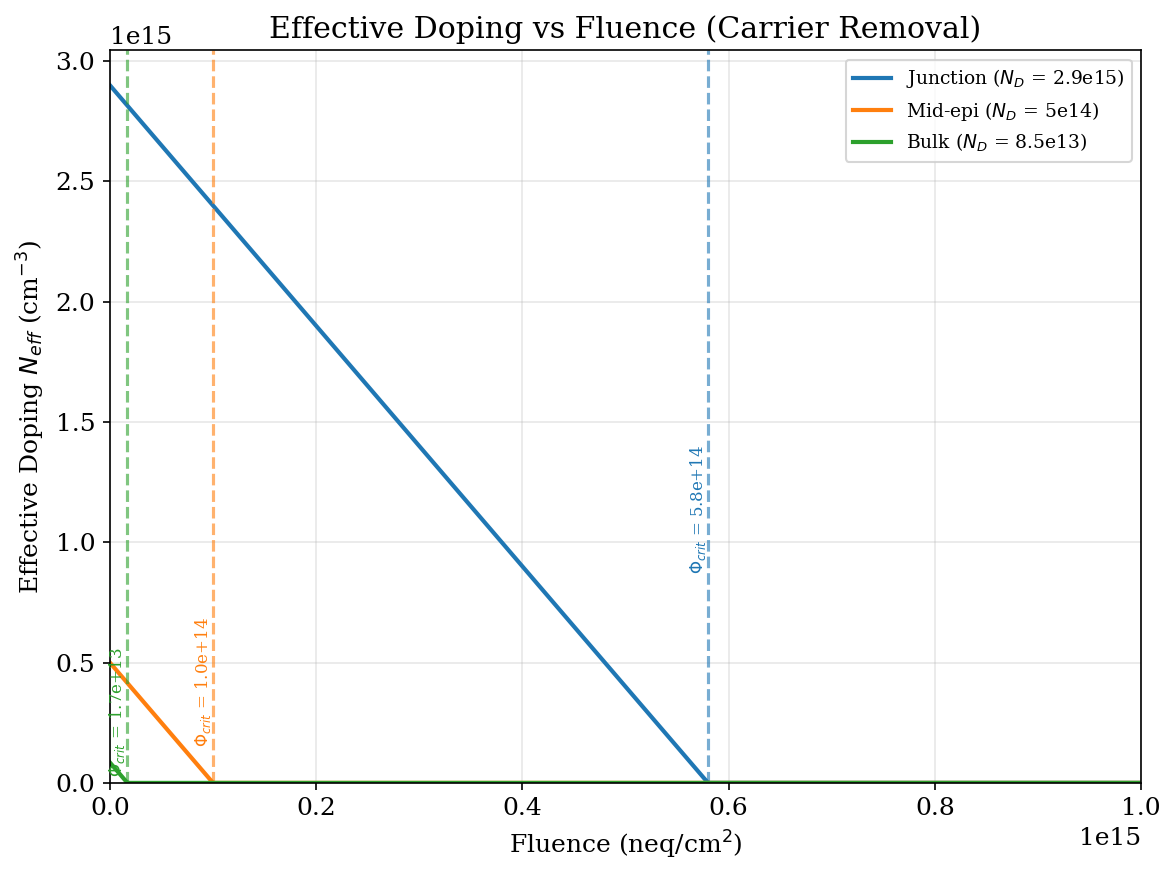

Saved: figures/09_carrier_removal.png


In [4]:
# Carrier Removal / Effective Doping vs Fluence
eta = params.eta_removal
doping_levels = {
    "Junction ($N_D$ = 2.9e15)": 2.9e15,
    "Mid-epi ($N_D$ = 5e14)": 5e14,
    "Bulk ($N_D$ = 8.5e13)": 8.5e13,
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(8, 6))

fluence_lin = np.linspace(0, 1e15, 500)

for (label, N_D), color in zip(doping_levels.items(), colors):
    N_eff = np.array([effective_doping(N_D, eta, phi) for phi in fluence_lin])
    ax.plot(fluence_lin, N_eff, label=label, color=color, lw=2)
    
    # Mark Phi_crit
    Phi_crit = N_D / eta
    ax.axvline(Phi_crit, color=color, ls="--", alpha=0.6)
    ax.annotate(
        f"$\\Phi_{{crit}}$ = {Phi_crit:.1e}",
        xy=(Phi_crit, N_D * 0.3),
        fontsize=8,
        color=color,
        rotation=90,
        va="bottom",
        ha="right",
    )

ax.set_xlabel("Fluence (neq/cm$^2$)")
ax.set_ylabel("Effective Doping $N_{eff}$ (cm$^{-3}$)")
ax.set_title("Effective Doping vs Fluence (Carrier Removal)")
ax.legend(fontsize=9)
ax.set_xlim(0, 1e15)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/09_carrier_removal.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/09_carrier_removal.png")

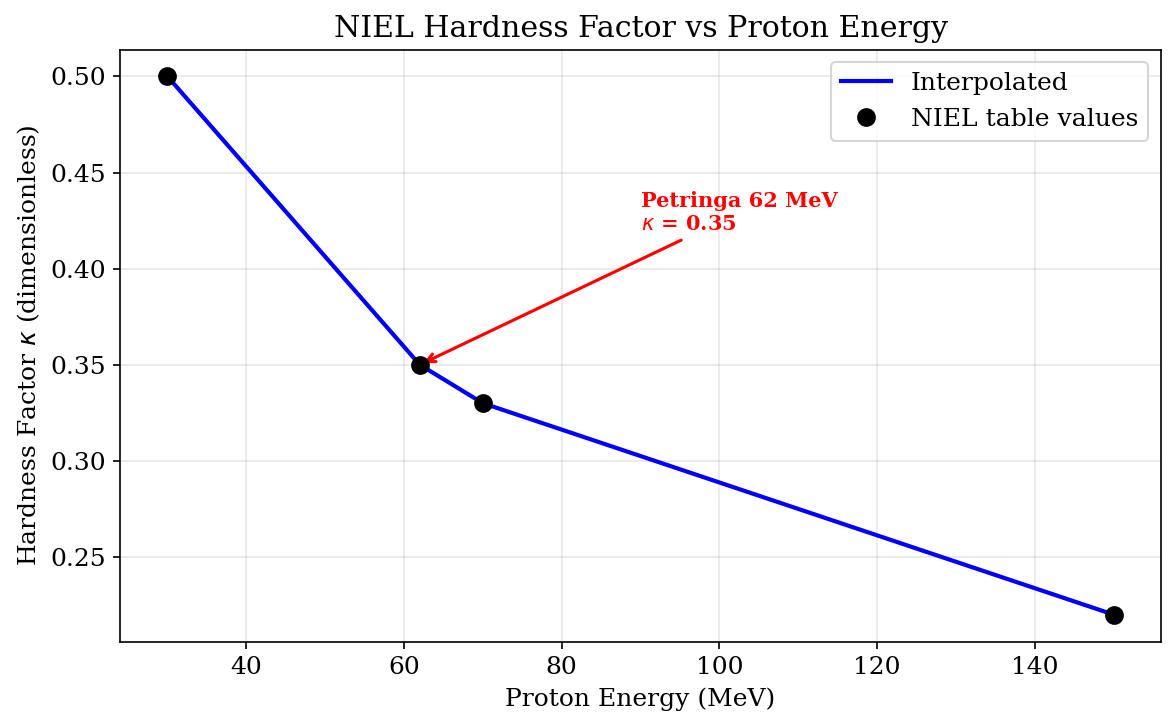

Saved: figures/09_niel_scaling.png


In [5]:
# NIEL Hardness Factor vs Proton Energy
energies = sorted(NIEL_HARDNESS_PROTON_SIC.keys())
factors = [NIEL_HARDNESS_PROTON_SIC[e] for e in energies]

# Interpolated curve
energy_fine = np.linspace(min(energies), max(energies), 200)
factor_fine = np.interp(energy_fine, energies, factors)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(energy_fine, factor_fine, "b-", lw=2, label="Interpolated")
ax.plot(energies, factors, "ko", ms=8, zorder=5, label="NIEL table values")

# Annotate reference beam energy
kappa_62 = NIEL_HARDNESS_PROTON_SIC[62]
ax.annotate(
    f"Reference 62 MeV\n$\\kappa$ = {kappa_62}",
    xy=(62, kappa_62),
    xytext=(90, 0.42),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    color="red",
    fontweight="bold",
)

ax.set_xlabel("Proton Energy (MeV)")
ax.set_ylabel("Hardness Factor $\\kappa$ (dimensionless)")
ax.set_title("NIEL Hardness Factor vs Proton Energy")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/09_niel_scaling.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/09_niel_scaling.png")

In [6]:
# Combined Damage Summary at Representative Fluences
from src.radiation_damage import compute_damaged_params, get_hardness_factor

tau_n_0 = 1e-6
tau_p_0 = 1e-6
N_D_profile = np.array([2.9e15, 5e14, 8.5e13])
energy_MeV = 62.0
kappa = get_hardness_factor(energy_MeV)

rows = []
for fluence_proton in [1e12, 1e13, 1e14]:
    r = compute_damaged_params(
        tau_n_0, tau_p_0, N_D_profile.copy(), fluence_proton, energy_MeV=energy_MeV
    )
    rows.append({
        "Proton Fluence (p/cm2)": f"{fluence_proton:.0e}",
        "neq Fluence (neq/cm2)": f"{r['fluence_neq']:.2e}",
        "tau_n (us)": f"{r['tau_n']*1e6:.4f}",
        "tau_p (us)": f"{r['tau_p']*1e6:.4f}",
        "N_eff junction (cm-3)": f"{r['N_D_profile'][0]:.2e}",
        "N_eff bulk (cm-3)": f"{r['N_D_profile'][2]:.2e}",
        "N_Z12 (cm-3)": f"{r['N_Z12']:.2e}",
    })

df = pd.DataFrame(rows)
print("Radiation Damage Summary at 62 MeV Proton Energy")
print(f"NIEL hardness factor kappa = {kappa}")
print()
df

Effective doping below 1e10 cm^-3 at 1 position(s) -- approaching full compensation. Fluence_neq=3.50e+13


Radiation Damage Summary at 62 MeV Proton Energy
NIEL hardness factor kappa = 0.35



,Proton Fluence (p/cm2),neq Fluence (neq/cm2),tau_n (us),tau_p (us),N_eff junction (cm-3),N_eff bulk (cm-3),N_Z12 (cm-3)
0,1e+12,3.50e+11,0.0135,0.4074,2.90e+15,8.32e+13,1.75e+12
1,1e+13,3.50e+12,0.0014,0.0643,2.88e+15,6.75e+13,1.75e+13
2,1e+14,3.50e+13,0.0001,0.0068,2.72e+15,0.00e+00,1.75e+14


## Summary

### Key Findings

1. **Z1/2 dominates** defect introduction with $\eta = 5.0$ cm$^{-1}$, the highest among the three defect types.
   At $10^{14}$ neq/cm$^2$, Z1/2 concentration reaches $5 \times 10^{14}$ cm$^{-3}$.

2. **Fluence range of interest:** Damage becomes significant above $\sim 10^{12}$ neq/cm$^2$:
   - Lifetime drops below 50% of pristine value
   - Carrier removal begins to affect bulk doping

3. **Critical fluence estimates** ($\Phi_{crit} = N_D / \eta$):
   - Bulk (8.5e13 cm$^{-3}$): $\Phi_{crit} \approx 1.7 \times 10^{13}$ neq/cm$^2$ -- compensated first
   - Mid-epi (5e14 cm$^{-3}$): $\Phi_{crit} \approx 1.0 \times 10^{14}$ neq/cm$^2$
   - Junction (2.9e15 cm$^{-3}$): $\Phi_{crit} \approx 5.8 \times 10^{14}$ neq/cm$^2$

4. **Lifetime models diverge** above $10^{13}$ neq/cm$^2$; logarithmic model ($\alpha=0.8$) predicts
   less severe degradation due to effective trap filling.

### Placeholder Values

NIEL hardness factors are placeholders. The 62 MeV value ($\kappa = 0.35$) must be validated
against SR-NIEL calculator output before production use.

### Next Steps

Phase 14 will couple these damage parameters to the devsim TCAD solver for CCE prediction
under irradiation, using the fluence-as-temperature architecture pattern.